In [3]:
!pip install pandas numpy
!pip install lxml

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.0 MB 3.8 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.0 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 2.6/4.0 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 3.4/4.0 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.8 MB/s  0:00:01



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [6]:
URL="https://web.archive.org/web/20230902185326/https://en.wikipedia.org/wiki/List_of_countries_by_GDP_%28nominal%29"
tables = pd.read_html(URL)

In [7]:
len(tables)

8

In [9]:
df = tables[3]
df.head()

Country/Territory UN region IMF[1][13]            World Bank[14]             \
  Country/Territory UN region   Estimate       Year       Estimate       Year   
0             World         —  105568776       2023      100562011       2022   
1     United States  Americas   26854599       2023       25462700       2022   
2             China      Asia   19373586  [n 1]2023       17963171  [n 3]2022   
3             Japan      Asia    4409738       2023        4231141       2022   
4           Germany    Europe    4308854       2023        4072192       2022   

  United Nations[15]             
            Estimate       Year  
0           96698005       2021  
1           23315081       2021  
2           17734131  [n 1]2021  
3            4940878       2021  
4            4259935       2021

In [10]:
df.shape

(214, 8)

In [11]:
df.columns = range(df.shape[1])

In [12]:
df = df[[0, 2]]

In [13]:
df = df.iloc[1:11, :]

In [14]:
df.columns = ['Country', 'GDP (Million USD)']

In [15]:
df['GDP (Million USD)'] = df['GDP (Million USD)'].astype(int)

In [16]:
df[['GDP (Million USD)']] = df[['GDP (Million USD)']] / 1000

In [17]:
df[['GDP (Million USD)']] = np.round(
    df[['GDP (Million USD)']], 2
)

In [18]:
df.rename(
    columns={'GDP (Million USD)': 'GDP (Billion USD)'},
    inplace=True
)

In [19]:
df

,Country,GDP (Billion USD)
1,United States,26854.60
2,China,19373.59
3,Japan,4409.74
4,Germany,4308.85
5,India,3736.88
6,United Kingdom,3158.94
7,France,2923.49
8,Italy,2169.74
9,Canada,2089.67
10,Brazil,2081.24


In [ ]:
df.to_csv('./Largest_economies.csv', index=False)

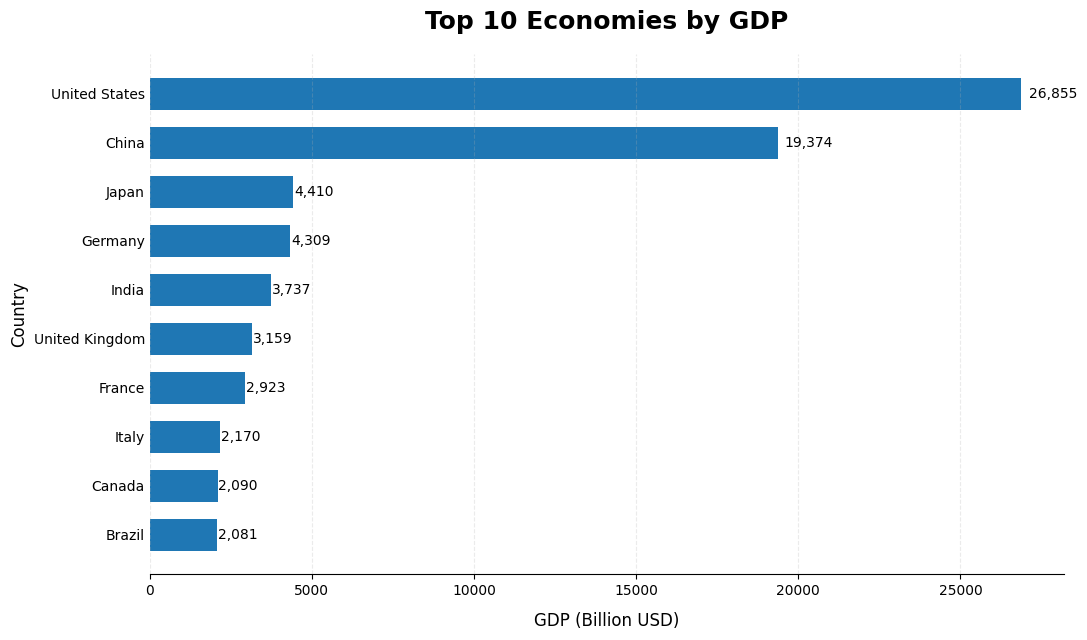

In [27]:
import matplotlib.pyplot as plt

# Sort GDP from smallest to largest
df = df.sort_values('GDP (Billion USD)')

plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    df['Country'],
    df['GDP (Billion USD)'],
    height=0.65
)

# Title and labels
plt.title(
    'Top 10 Economies by GDP',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'GDP (Billion USD)',
    fontsize=12,
    labelpad=10
)

plt.ylabel('Country', fontsize=12)

# Add values
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + width * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        fontsize=10
    )

# Clean appearance
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

In [26]:
df.to_csv(r"C:\Users\USER\Desktop\Largest_economies.csv", index=False)